# Lab 04-1 Perceptron, Adaline, and Optimization
## 112078502 

Assignment

Implement the Adaline with SGD which can set different batch_size (M) as parameter. Then, use the Iris dataset to fit your model with 3 different M (including M=1) and fixed learning rate η and print out the accuracy of each model. Last, plot the cost against the number of epochs using different M in one figure.

Requirements:  

* Submit to eeclass with your code file Lab04-1_{student_id}.ipynb and image file Lab04-1_{student_id}.png (e.g. Lab04-1_110069999.ipynb).


To simplfy your work, you can ignore part of data which is not divisible by M.

Your code file should contain:
## TODO
1. Split training and testing data (test_size = 20% of the whole dataset)
2. Handcrafted Adaline classifier with M as parameter.
3. Fit model with 3 different M and fixed η. (including M=1)
4. Print the accuracy of each model.
5. Plot the cost against the number of epochs using different M in one figure. Your image file should contain: Figure of the cost against the number of epochs using different M.

## TODO1
1. Split training and testing data (test_size = 20% of the whole dataset)

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display

df = pd.read_csv('https://archive.ics.uci.edu/ml/'
        'machine-learning-databases/iris/iris.data', header=None)
df.columns = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'Class label']
display(df.head())

X = df[['Petal length', 'Petal width']].values
y = pd.factorize(df['Class label'])[0]

# discard exmaples in the first class
X = X[50:150]
y = np.where(y[50:150] == 2, -1, y[50:150])

# TODO1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

print('# Training data points: %d' % X_train.shape[0])
print('# Testing data points: %d' % X_test.shape[0])
print('Class labels: %s' % np.unique(y))

,Sepal length,Sepal width,Petal length,Petal width,Class label
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Training data points: 80
# Testing data points: 20
Class labels: [-1  1]


## TODO 2
2. Handcrafted Adaline classifier with M as parameter.

In [46]:
class AdalineSGD(object):
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
    M : int
        Batch size for SGD

    Attributes
    -----------
    w_ : 1d-array
        Weights after fitting.
    errors_ : list
        Number of misclassifications in every epoch.
    shuffle : bool (default: True)
        Shuffles training data every epoch if True to prevent cycles.
    random_state : int
        Set random state for shuffling and initializing the weights.

    """
    # def __init__(self, eta=0.01, n_iter=50, shuffle=True, random_state=1):
    def __init__(self, eta=0.01, n_iter=50, shuffle=True, random_state=1, M=1):
        self.eta = eta
        self.n_iter = n_iter
        self.shuffle = shuffle
        self.M = M
        if random_state:
            np.random.seed(random_state)

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : array-like; shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like; shape = [n_samples]
            Target values or labels.

        Returns
        -------
        self : object

        """
        self._initialize_weights(X.shape[1])
        self.cost_ = []
        for _ in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            cost_sum = 0
            n_batches = 0 # fix

            for i in range(X.shape[0] // self.M):
                begin = i * self.M
                end = begin + self.M
                cost_sum += self._update_weights(X[begin:end], y[begin:end])
                n_batches += 1  
            self.cost_.append(cost_sum / n_batches)
        return self

    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = np.random.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        """Randomly initialize weights"""
        self.w_ = np.random.normal(loc=0.0, scale=0.01, size=1 + m)

    def _update_weights(self, Xb, yb):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(Xb)

        # Cost function
        error = (yb - output)
        # cost = 0.5 * np.sum(error ** 2)
        cost = 0.5 * np.mean(error ** 2)

        # # Update rule
        # self.w_[1:] += self.eta * Xb.T.dot(error)
        # self.w_[0] += self.eta * error.sum()
        self.w_[1:] += self.eta * Xb.T.dot(error) / len(yb) # fix
        self.w_[0]  += self.eta * error.mean()

        return cost

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Compute linear activation"""
        return self.net_input(X)

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(X) >= 0.0, 1, -1)

## TODO 3, 4
3. Fit model with 3 different M and fixed η. (including M=1) -> fixed at 0.01 as in TA example
4. Print the accuracy of each model.

In [55]:
from sklearn.metrics import accuracy_score
# (self, eta=0.01, n_iter=50, shuffle=True, random_state=1, M=1):
def fit_evaluate(batch_size):
    model = AdalineSGD(eta=0.01, n_iter=20, random_state=1, M= batch_size)
    model.fit(X_train_std, y_train)

    y_pred = model.predict(X_test_std)
    print(f'batch_size={batch_size}')
    print('Misclassified samples: %d' % (y_test != y_pred).sum())
    print('Accuracy: %.2f\n' % accuracy_score(y_test, y_pred))
    return model

print("=== Evaluate AdalineSGD === \n")
adas1 = fit_evaluate(1)
adas2 = fit_evaluate(10)
adas3 = fit_evaluate(40)

=== Evaluate AdalineSGD === 

batch_size=1
Misclassified samples: 3
Accuracy: 0.85

batch_size=10
Misclassified samples: 3
Accuracy: 0.85

batch_size=40
Misclassified samples: 2
Accuracy: 0.90



## TODO 5
5. Plot the cost against the number of epochs using different M in one figure. Your image file should contain: Figure of the cost against the number of epochs using different M.

Note:  
As the batch size increases, the convergence of Adaline becomes slower because each epoch performs fewer parameter updates. Smaller batch sizes converge faster in early epochs due to more frequent updates, but exhibit higher stochasticity. Larger batch sizes produce smoother and more stable learning curves, though they require more epochs to reach the same minimum. Overall, all batch sizes converge to a similar solution, consistent with the convex nature of the Adaline objective function

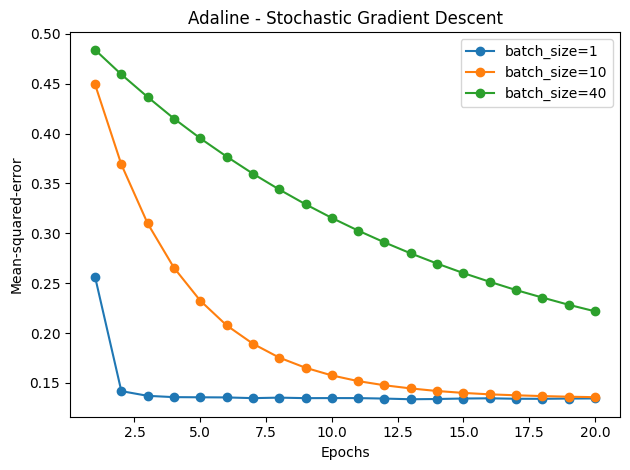

In [56]:
'''plot'''
import matplotlib.pyplot as plt

plt.plot(range(1, len(adas1.cost_) + 1), adas1.cost_,
         marker='o', label=f'batch_size={adas1.M}')
plt.plot(range(1, len(adas2.cost_) + 1), adas2.cost_,
         marker='o', label=f'batch_size={adas2.M}')
plt.plot(range(1, len(adas3.cost_) + 1), adas3.cost_,
         marker='o', label=f'batch_size={adas3.M}')
         
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('Mean-squared-error')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('./Lab04-1_112078502.png', dpi=300)
plt.show()